In [2]:
import FinanceDataReader as fdr
import numpy as np
import matplotlib.pyplot as plt



In [11]:
samsung = fdr.DataReader('005930', '2020')
print(samsung.head())

             Open   High    Low  Close    Volume    Change
Date                                                      
2020-01-02  55500  56000  55000  55200  12993228 -0.010753
2020-01-03  56000  56600  54900  55500  15422255  0.005435
2020-01-06  54900  55600  54600  55500  10278951  0.000000
2020-01-07  55700  56400  55600  55800  10009778  0.005405
2020-01-08  56200  57400  55900  56800  23501171  0.017921


## 정규화하자

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))

scaled_data=scaler.fit_transform(samsung[['Open']].values.reshape(-1,1))
print(scaled_data[:5])

[[0.13263158]
 [0.12652632]
 [0.12715789]
 [0.12273684]
 [0.12242105]]


In [ ]:
import numpy as np

def make_samsung_data(data, window):
  train=[]
  target=[]
  for i in range(data.size-window):
    train.append(data[i:i+window]) # 이게 핵심인데... n개씩 묶고
    target.append(data[i+window]) # n 개씩에 대한 1개의 정답표
  return np.array(train), np.array(target)

In [14]:
TEST_SIZE =200
train_data=scaled_data[:-TEST_SIZE]
test_data = scaled_data[-TEST_SIZE:]



In [15]:
(X_train, y_train)=make_samsung_data(train_data, 30)
(X_test, y_test)=make_samsung_data(test_data, 30)

In [16]:
print(X_train.shape)

(2255, 30, 1)


In [19]:
print(y_train.shape)

(2255, 1)


In [20]:
print(y_train[0])

[0.12663158]


In [21]:
import tensorflow as tf

model = tf.keras.models.Sequential()
input_layer = tf.keras.layers.Input(shape=(30,1))
model.add(input_layer)

model.add(tf.keras.layers.LSTM(128, return_sequences=True, activation='tanh'))
model.add(tf.keras.layers.LSTM(64, return_sequences=True, activation='tanh'))
model.add(tf.keras.layers.LSTM(1, return_sequences=False, activation='sigmoid'))

model.summary()



2026-02-20 15:12:27.044660: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-20 15:12:27.073917: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-20 15:12:28.003945: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-20 15:12:29.329175: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,232 (454.03 KB)

 Trainable params: 116,232 (454.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['accuracy']) # 회귀문제니까 mse(mean squared error)로 손실함수 설정


In [23]:
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0013 - loss: 0.0077
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.0013 - loss: 6.0220e-04
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0013 - loss: 4.1731e-04
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0013 - loss: 3.8629e-04
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0013 - loss: 3.6076e-04
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.0013 - loss: 3.3445e-04
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0013 - loss: 3.3904e-04    
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0013 - loss: 3.2415e-04 
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0013 - loss: 2.9293e-04
Epoch 10/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0013 - loss: 2.9578e-04
Epoch 11/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.0013 - loss: 2.8923e-04
Epoch 1

In [24]:
model.save('samsung_model.keras')

In [25]:
predicts = model.predict(X_test)
print(predicts[:5])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.3121676 ]
 [0.31344786]
 [0.31653297]
 [0.30291882]
 [0.30005327]]


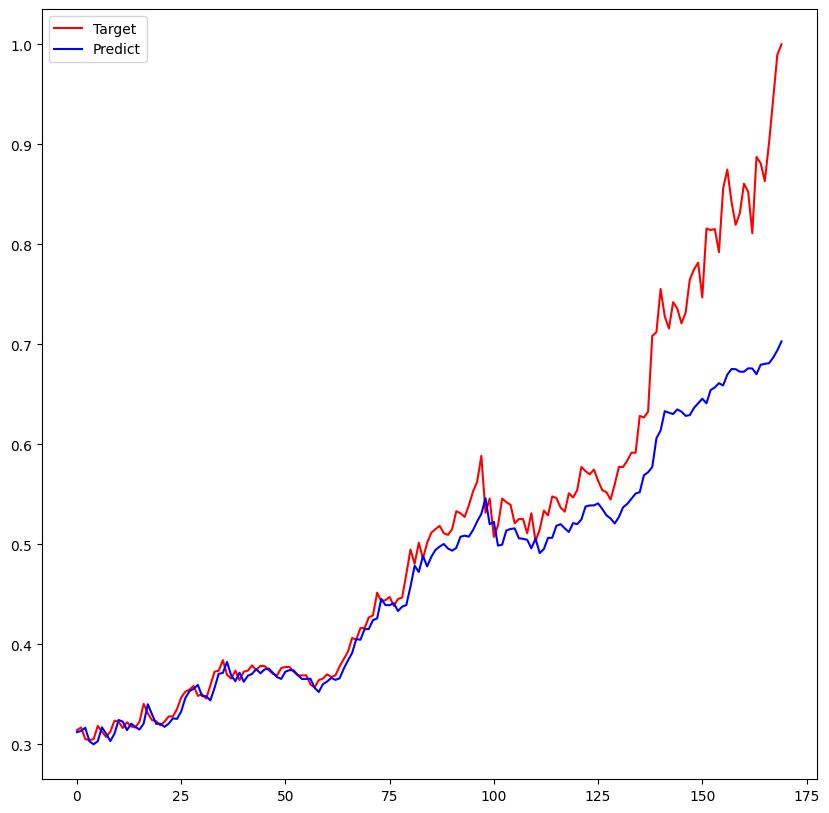

In [28]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,10))
plt.plot(y_test, color='red', label='Target')
plt.plot(predicts, color='blue', label='Predict')
plt.legend()
plt.show()

In [ ]:
plt.plot